Some simple statistics

In [1]:
import os
import glob
import numpy as np # for arrays
import pandas as pd # for importing csv files
from pathlib import Path
import matplotlib.pyplot as plt

Read file extensions and plot them. I expect m4a, mp3, wav and opus

In [8]:
# folder that contains two subfolders "germany" and "usa"
measCsv=r'C:\Users\t_ziemer\Desktop\techno-mfcc'
folds=glob.glob(str(measCsv+'\\*'))
# dictionary of all features:
features = {1: 'MFCC1',
            2: 'MFCC2',
            3: 'MFCC3',
            4: 'MFCC4',
            5: 'MFCC5',
            6: 'MFCC6',
            7: 'MFCC7',
            8: 'MFCC8',
            9: 'MFCC9',
            10: 'MFCC10',
            11: 'MFCC11',
            12: 'MFCC12',
            13: 'MFCC13',
            14: 'SpectralCentroid',
            15: 'SpectralRolloff',
            16: 'SpectralFlatness',
            17: 'SpectralBandwidth',
            18: 'ZeroCrossingRate'}

# selection of preferred features
nfeatures = {0: 1,
             1: 2,
             2: 3,
             3: 4,
             4:5, 5:6, 6:7, 7:8, 8:9, 9:10, 10:11, 11:12, 12:13, 13:14, 14:15, 15:16, 16:17, 17:18
            }
numfeatures = len(nfeatures)

In [9]:
# median: takes forever, only works when ALL filenames are correct

train_X = []
target = []
MFCC1 = []
MFCC2 = []
MFCC3 = []
MFCC4 = []

MFCC5 = []
MFCC6 = []
MFCC7 = []
MFCC8 = []

MFCC9 = []
MFCC10 = []
MFCC11 = []
MFCC12 = []

MFCC13 = []
SpectralCentroid = []
SpectralRolloff = []
SpectralFlatness = []

SpectralBandwidth = []
ZeroCrossingRate = []
SpectralBandwidth_mid = []
SpectralBandwidth_high = []

color_map = {}
nation = []
year = []
filename = []

# give the classes their names
labels=['Germany','USA']

for cl, fold in enumerate(folds):
    files = glob.glob(str(fold+'\*.csv'))
    numfiles = len(fold)
    lal1 = np.empty((numfiles, numfeatures))
    for j, f in enumerate(files):
        la = pd.read_csv(f, index_col=0)
        #print(f)
        MFCC1.append(la[features[nfeatures[0]]].median())
        MFCC2.append(la[features[nfeatures[1]]].median())
        MFCC3.append(la[features[nfeatures[2]]].median())
        MFCC4.append(la[features[nfeatures[3]]].median())
        MFCC5.append(la[features[nfeatures[4]]].median())
        MFCC6.append(la[features[nfeatures[5]]].median())
        MFCC7.append(la[features[nfeatures[6]]].median())
        MFCC8.append(la[features[nfeatures[7]]].median())
        MFCC9.append(la[features[nfeatures[8]]].median())
        MFCC10.append(la[features[nfeatures[9]]].median())
        MFCC11.append(la[features[nfeatures[10]]].median())
        MFCC12.append(la[features[nfeatures[11]]].median())
        MFCC13.append(la[features[nfeatures[12]]].median())
        SpectralCentroid.append(la[features[nfeatures[13]]].median())
        SpectralRolloff.append(la[features[nfeatures[14]]].median())
        SpectralFlatness.append(la[features[nfeatures[15]]].median())
        SpectralBandwidth.append(la[features[nfeatures[16]]].median())
        ZeroCrossingRate.append(la[features[nfeatures[17]]].median())    
        
        #reads the year from the filename:
        if f[-5]=='s':# opus files
            year.append(int(f[-14:-10]))
            opus = -16
        else:# for mp3/m4a/wav files
            year.append(int(f[-13:-9]))
            opus = -15
        if fold[-1]=='y':# for the "germany" folder
            filename.append(f[46:opus])# this number depends on absolute file path
        else:
            filename.append(f[42:opus])# this number depends on absolute file path
            #print(f[45:-16])
        nation.append(labels[cl])
        
# ensures that every song has a valid year
nan_indices = [index for index, value in enumerate(train_X) if np.isnan(value)]
print(nan_indices)

# produces a massive csv file that contains all releven info
matrix = np.array([filename,nation,year,MFCC1,MFCC2,MFCC3,MFCC4,MFCC5,MFCC6,MFCC7,MFCC8,MFCC9,MFCC10,MFCC11,MFCC12,MFCC13,SpectralCentroid,SpectralRolloff,SpectralFlatness,SpectralBandwidth,ZeroCrossingRate])
matrix = matrix.transpose()
df = pd.DataFrame(matrix, columns=['Song','Nation', 'Year','MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6','MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12','MFCC13','SpectralCentroid','SpectralRolloff','SpectralFlatness','SpectralBandwidth','ZeroCrossingRate'])
csvfilename = r'C:\python\gits\early-techno\matrix25-12-21-allMFCCmedian.csv'

# Save the array to a CSV file
df.to_csv(csvfilename, index=False, header=True)

C:\Users\t_ziemer\Desktop\techno-mfcc\germany\100 Prozent - Eclypse (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\100 Prozent - Power Of The Light (100 Prozent-Mix) (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\100 Prozent - Power Of The Light (Radio Edit) (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\1000 Micro Dats - The Centre (Tuned Mix) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\16 Bit - Where are you (1986).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\2 German Latinos - Gigolo Gigolette (Delkom Dance Mix) (1989).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\2 German Latinos - Viva La Droga Electronica (Subliminal Style) (1991).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\2 German Latinos - Yo Soy Tu Droga (Dominant Style) (1991).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\2 Megabite - Beat The Feet (Insert Disk Version) (1990).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany

C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acid Scout - Ma' Lady (1994).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acid Scout - Mondonon (1994).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acid-Pin-Ups - Betty 101 (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acid-Pin-Ups - Cathleen 909 (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acid-Pin-Ups - Heather 202 (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acid-Pin-Ups - Ivonne 808 (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acid-Pin-Ups - Marilyn 404 (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acrid Abeyance - 303 Delight (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acrid Abeyance - 303 In Love (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acrid Abeyance - Acid Blubber (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Acrid Abeyance - Crying Bassline (1993).m4a.csv
C:\Users\t_ziemer\Desktop\

C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Christ - The Eagle Has Landed (1993).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Christ - The Frequencies Of Fear (1993).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - All Night Until Day Light (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - Alpha Music (1993).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - Beta Music (Hanover Rmx) (1993).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - Beta Music (Lo Budget Rmx) (1993).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - Beta Music (UCT Rmx) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - Big Brother (Heavy Mix) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - Big Brother (Trance Mix) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Alien Factory - Delta Music (1993).mp3.csv
C:\Users\t_ziem

C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arpeggiators - Freedom Of Expression (Braincell Mix) (1994).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arpeggiators - Helter Skelter (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arpeggiators - Trancemission (1992).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arpeggiators - X-plain The Un-x-plained (Resistance D Mix) (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Art Academy - Energie (1990).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Art Academy - The banker (1990).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Art Academy - The Banker (HWSK Mix) (1990).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arte Bionico - Bionico (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arte Bionico - Neon Jungle (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arte Bionico - Voyage Bionico (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Arte Bion

C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - Barbarella (The Secret Chamber Of Dreams) (1992).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - Barbarella 2000 (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - Barbarella 4 (The Future) (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - Barbarella Butterfly (1992).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - Barbarella I (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - Barbarella II (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - My Name Is Barbarella (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - The Future (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - The Mission (1992).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarella - The Secret Chamber Of Dreams (1992).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\germany\Barbarel

...

C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Todd Terry - When You Hold Me (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Todd Terry - Work Your Butt (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Todd Terry - Year Of The Rock (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Tone Nice - Keep On (Chez-D-Rest Mix) (1992).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Tone Nice - Keep On (Techno Soul Mix) (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Tony Sineni - Rhythm Of The Beat (Kenny's Mix) (1987).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Tony Sineni - Rhythm Of The Beat (Slam Mix) (1987).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Total Capacity - Ambience (Dub Mix) (1991).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Total Capacity - Ambience (Red Head Mix) (1991).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Touch - Fallen (Bassappella & Dub Version) (1988).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Touch - Fa

C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project - Love Don't Let Go (92 Remix) (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project - Now I Know I Love U (E-Smoove's Funk Revival) (1993).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project - Now I Know I Love U (Maurice's Club Mix) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project - Now I Know I Love U (The Don's Dub) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project - Now I Know I Love U (UBQ's Underground Mix) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project - We Can Make It (Aaron's Big House Remix) (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project - We Can Make It (Terry's Original Mix) (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\UBQ Project Feat. Kathy Summers - Feel My Soul (Chicago Mix) (1991).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Umosia - Love Don't Let Me Down (Dub Mix) (1992).opus.csv
C:\Users\t

C:\Users\t_ziemer\Desktop\techno-mfcc\usa\United States of Nervous - Fxtc Gets Nervous Again Nervous (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Urban Culture - The Wonders Of Wishing (For Me) (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Urban Culture - The Wonders Of Wishing (For You) (1992).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Urban Native Sons - Of The Native (It's Terrence Parker's House!) (1993).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Van Helden Presents Jungle Juice - Loves Ecstasy (Peak Hour Mix) (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Van Helden Presents Jungle Juice - Loves Ecstasy (Shake And Break Mix) (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Veda Simpson - Oohhh Baby (Club Mix) (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Veda Simpson - Oohhh Baby (Dub #1) (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Veda Simpson - Oohhh Baby (Dub #2) (1994).m4a.csv
C:\Users\t_ziemer\Des

C:\Users\t_ziemer\Desktop\techno-mfcc\usa\White Knight - White Knight Jacks (Knight Dub Mix) (1987).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\White Knight - Yo Baby Yo (Mix 1) (1987).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\White Knight - Yo Baby Yo (Mix 2) (1987).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\White Knight - Yo Baby Yo (Mix 3) (1987).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\White Knight Sycho feat. Flex - Redrum (Extended Mix) (1994).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Whitney Houston - I'm Every Woman (1992).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Whitney Houston - I'm Your Baby Tonight (Extended Remix) (1990).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Will Downing - A Love Supreme (Dub In The House Remix) (1988).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Will Downing - Come Together As One (Dream Together Version) (1990).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Will Downing - Come Together 

C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Z-Factor feat. Jesse Saunders - I Am The DJ (1984).mp3.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Z-Factor feat. Jesse Saunders - Thorns (1984).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Zage 1 1-14 - Funtime (Black) (1993).opus.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Zage 1 1-14 - Funtime (Chill Mix) (1993).m4a.csv
C:\Users\t_ziemer\Desktop\techno-mfcc\usa\Zage 1 1-14 - Funtime (Free Fall) (1993).m4a.csv
[]


Means:

In [ ]:
# means: takes forever, only works when ALL filenames are correct
train_X = []
target = []
MFCC1 = []
MFCC2 = []
MFCC3 = []
MFCC4 = []

MFCC5 = []
MFCC6 = []
MFCC7 = []
MFCC8 = []

MFCC9 = []
MFCC10 = []
MFCC11 = []
MFCC12 = []

MFCC13 = []
SpectralCentroid = []
SpectralRolloff = []
SpectralFlatness = []

SpectralBandwidth = []
ZeroCrossingRate = []

color_map = {}
nation = []
year = []
filename = []

# give the classes their names
labels=['Germany','USA']

for cl, fold in enumerate(folds):
    files = glob.glob(str(fold+'\*.csv'))
    numfiles = len(fold)
    lal1 = np.empty((numfiles, numfeatures))
    #print(lal1)
    for j, f in enumerate(files):
        la = pd.read_csv(f, index_col=0)
        MFCC1.append(la[features[nfeatures[0]]].mean())
        MFCC2.append(la[features[nfeatures[1]]].mean())
        MFCC3.append(la[features[nfeatures[2]]].mean())
        MFCC4.append(la[features[nfeatures[3]]].mean())
        MFCC5.append(la[features[nfeatures[4]]].mean())
        MFCC6.append(la[features[nfeatures[5]]].mean())
        MFCC7.append(la[features[nfeatures[6]]].mean())
        MFCC8.append(la[features[nfeatures[7]]].mean())
        MFCC9.append(la[features[nfeatures[8]]].mean())
        MFCC10.append(la[features[nfeatures[9]]].mean())
        MFCC11.append(la[features[nfeatures[10]]].mean())
        MFCC12.append(la[features[nfeatures[11]]].mean())
        MFCC13.append(la[features[nfeatures[12]]].mean())
        SpectralCentroid.append(la[features[nfeatures[13]]].mean())
        SpectralRolloff.append(la[features[nfeatures[14]]].mean())
        SpectralFlatness.append(la[features[nfeatures[15]]].mean())
        SpectralBandwidth.append(la[features[nfeatures[16]]].mean())
        ZeroCrossingRate.append(la[features[nfeatures[17]]].mean())  
        
        #print(f)
        if f[-5]=='s':
            #int(f[-13:-9])
            #print(int(f[-13:-9]))
            year.append(int(f[-14:-10]))
            opus = -16
        else:
            year.append(int(f[-13:-9]))
            opus = -15
        if fold[-1]=='y':
            filename.append(f[45:opus])# depends on absolute file path
        else:
            filename.append(f[41:opus])# depends on absolute file path
            #print(f[45:-16])
        nation.append(labels[cl])
        
matrix = np.array([filename,nation,year,MFCC1,MFCC2,MFCC3,MFCC4,MFCC5,MFCC6,MFCC7,MFCC8,MFCC9,MFCC10,MFCC11,MFCC12,MFCC13,SpectralCentroid,SpectralRolloff,SpectralFlatness,SpectralBandwidth,ZeroCrossingRate])
matrix = matrix.transpose()
df = pd.DataFrame(matrix, columns=['Song','Nation', 'Year','MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6','MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12','MFCC13','SpectralCentroid','SpectralRolloff','SpectralFlatness','SpectralBandwidth','ZeroCrossingRate'])
csvfilename = r'C:\python\gits\early-techno\matrix25-12-21-allMFCCmean.csv'

# Save the array to a CSV file
df.to_csv(csvfilename, index=False, header=True)

SDs:

In [15]:
# SDs: takes forever, ...
train_X = []
target = []
MFCC1 = []
MFCC2 = []
MFCC3 = []
MFCC4 = []

MFCC5 = []
MFCC6 = []
MFCC7 = []
MFCC8 = []

MFCC9 = []
MFCC10 = []
MFCC11 = []
MFCC12 = []

MFCC13 = []
SpectralCentroid = []
SpectralRolloff = []
SpectralFlatness = []

SpectralBandwidth = []
ZeroCrossingRate = []

color_map = {}
nation = []
year = []
filename = []

# give the classes their names
labels=['Germany','USA']

for cl, fold in enumerate(folds):
    files = glob.glob(str(fold+'\*.csv'))
    numfiles = len(fold)
    lal1 = np.empty((numfiles, numfeatures))
    #print(lal1)
    for j, f in enumerate(files):
        la = pd.read_csv(f, index_col=0)
        MFCC1.append(la[features[nfeatures[0]]].std())
        MFCC2.append(la[features[nfeatures[1]]].std())
        MFCC3.append(la[features[nfeatures[2]]].std())
        MFCC4.append(la[features[nfeatures[3]]].std())
        MFCC5.append(la[features[nfeatures[4]]].std())
        MFCC6.append(la[features[nfeatures[5]]].std())
        MFCC7.append(la[features[nfeatures[6]]].std())
        MFCC8.append(la[features[nfeatures[7]]].std())
        MFCC9.append(la[features[nfeatures[8]]].std())
        MFCC10.append(la[features[nfeatures[9]]].std())
        MFCC11.append(la[features[nfeatures[10]]].std())
        MFCC12.append(la[features[nfeatures[11]]].std())
        MFCC13.append(la[features[nfeatures[12]]].std())
        SpectralCentroid.append(la[features[nfeatures[13]]].std())
        SpectralRolloff.append(la[features[nfeatures[14]]].std())
        SpectralFlatness.append(la[features[nfeatures[15]]].std())
        SpectralBandwidth.append(la[features[nfeatures[16]]].std())
        ZeroCrossingRate.append(la[features[nfeatures[17]]].std())  
        
        #print(f)
        if f[-5]=='s':
            #int(f[-13:-9])
            #print(int(f[-13:-9]))
            year.append(int(f[-14:-10]))
            opus = -16
        else:
            year.append(int(f[-13:-9]))
            opus = -15
        if fold[-1]=='y':
            filename.append(f[45:opus])# depends on absolute file path
        else:
            filename.append(f[41:opus])# depends on absolute file path
            #print(f[45:-16])
        nation.append(labels[cl])
        
matrix = np.array([filename,nation,year,MFCC1,MFCC2,MFCC3,MFCC4,MFCC5,MFCC6,MFCC7,MFCC8,MFCC9,MFCC10,MFCC11,MFCC12,MFCC13,SpectralCentroid,SpectralRolloff,SpectralFlatness,SpectralBandwidth,ZeroCrossingRate])
matrix = matrix.transpose()
df = pd.DataFrame(matrix, columns=['Song','Nation', 'Year','MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6','MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12','MFCC13','SpectralCentroid','SpectralRolloff','SpectralFlatness','SpectralBandwidth','ZeroCrossingRate'])
csvfilename = r'C:\python\gits\early-techno\matrix25-12-21-allMFCCsd.csv'

# Save the array to a CSV file
df.to_csv(csvfilename, index=False, header=True)



Skewness

In [16]:
# skwew: takes forever, ...
train_X = []
target = []
MFCC1 = []
MFCC2 = []
MFCC3 = []
MFCC4 = []

MFCC5 = []
MFCC6 = []
MFCC7 = []
MFCC8 = []

MFCC9 = []
MFCC10 = []
MFCC11 = []
MFCC12 = []

MFCC13 = []
SpectralCentroid = []
SpectralRolloff = []
SpectralFlatness = []

SpectralBandwidth = []
ZeroCrossingRate = []

color_map = {}
nation = []
year = []
filename = []

# give the classes their names
labels=['Germany','USA']

for cl, fold in enumerate(folds):
    files = glob.glob(str(fold+'\*.csv'))
    numfiles = len(fold)
    lal1 = np.empty((numfiles, numfeatures))
    #print(lal1)
    for j, f in enumerate(files):
        la = pd.read_csv(f, index_col=0)
        MFCC1.append(la[features[nfeatures[0]]].skew())
        MFCC2.append(la[features[nfeatures[1]]].skew())
        MFCC3.append(la[features[nfeatures[2]]].skew())
        MFCC4.append(la[features[nfeatures[3]]].skew())
        MFCC5.append(la[features[nfeatures[4]]].skew())
        MFCC6.append(la[features[nfeatures[5]]].skew())
        MFCC7.append(la[features[nfeatures[6]]].skew())
        MFCC8.append(la[features[nfeatures[7]]].skew())
        MFCC9.append(la[features[nfeatures[8]]].skew())
        MFCC10.append(la[features[nfeatures[9]]].skew())
        MFCC11.append(la[features[nfeatures[10]]].skew())
        MFCC12.append(la[features[nfeatures[11]]].skew())
        MFCC13.append(la[features[nfeatures[12]]].skew())
        SpectralCentroid.append(la[features[nfeatures[13]]].skew())
        SpectralRolloff.append(la[features[nfeatures[14]]].skew())
        SpectralFlatness.append(la[features[nfeatures[15]]].skew())
        SpectralBandwidth.append(la[features[nfeatures[16]]].skew())
        ZeroCrossingRate.append(la[features[nfeatures[17]]].skew())    
        
        #print(f)
        if f[-5]=='s':
            #int(f[-13:-9])
            #print(int(f[-13:-9]))
            year.append(int(f[-14:-10]))
            opus = -16
        else:
            year.append(int(f[-13:-9]))
            opus = -15
        if fold[-1]=='y':
            filename.append(f[45:opus])# depends on absolute file path
        else:
            filename.append(f[41:opus])# depends on absolute file path
            #print(f[45:-16])
        nation.append(labels[cl])
        
matrix = np.array([filename,nation,year,MFCC1,MFCC2,MFCC3,MFCC4,MFCC5,MFCC6,MFCC7,MFCC8,MFCC9,MFCC10,MFCC11,MFCC12,MFCC13,SpectralCentroid,SpectralRolloff,SpectralFlatness,SpectralBandwidth,ZeroCrossingRate])
matrix = matrix.transpose()
df = pd.DataFrame(matrix, columns=['Song','Nation', 'Year','MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6','MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12','MFCC13','SpectralCentroid','SpectralRolloff','SpectralFlatness','SpectralBandwidth','ZeroCrossingRate'])
csvfilename = r'C:\python\gits\early-techno\matrix25-12-21-allMFCCskew.csv'

# Save the array to a CSV file
df.to_csv(csvfilename, index=False, header=True)

import numpy as np # for arrays
import pandas as pd # for importing csv files
from pathlib import Path
#csvfilename = r'C:\python\gits\early-techno\matrix25-02-22-all21median.csv'
#csvfilename = r'C:\python\gits\early-techno\matrix25-02-22-all21sd.csv'
#csvfilename = r'C:\python\gits\early-techno\matrix25-02-22-all21mean.csv'
csvfilename = r'C:\python\gits\early-techno\matrix25-12-21-allMFCCskew.csv'
df = pd.read_csv(csvfilename, index_col=False)

Check for Multicollinearity:

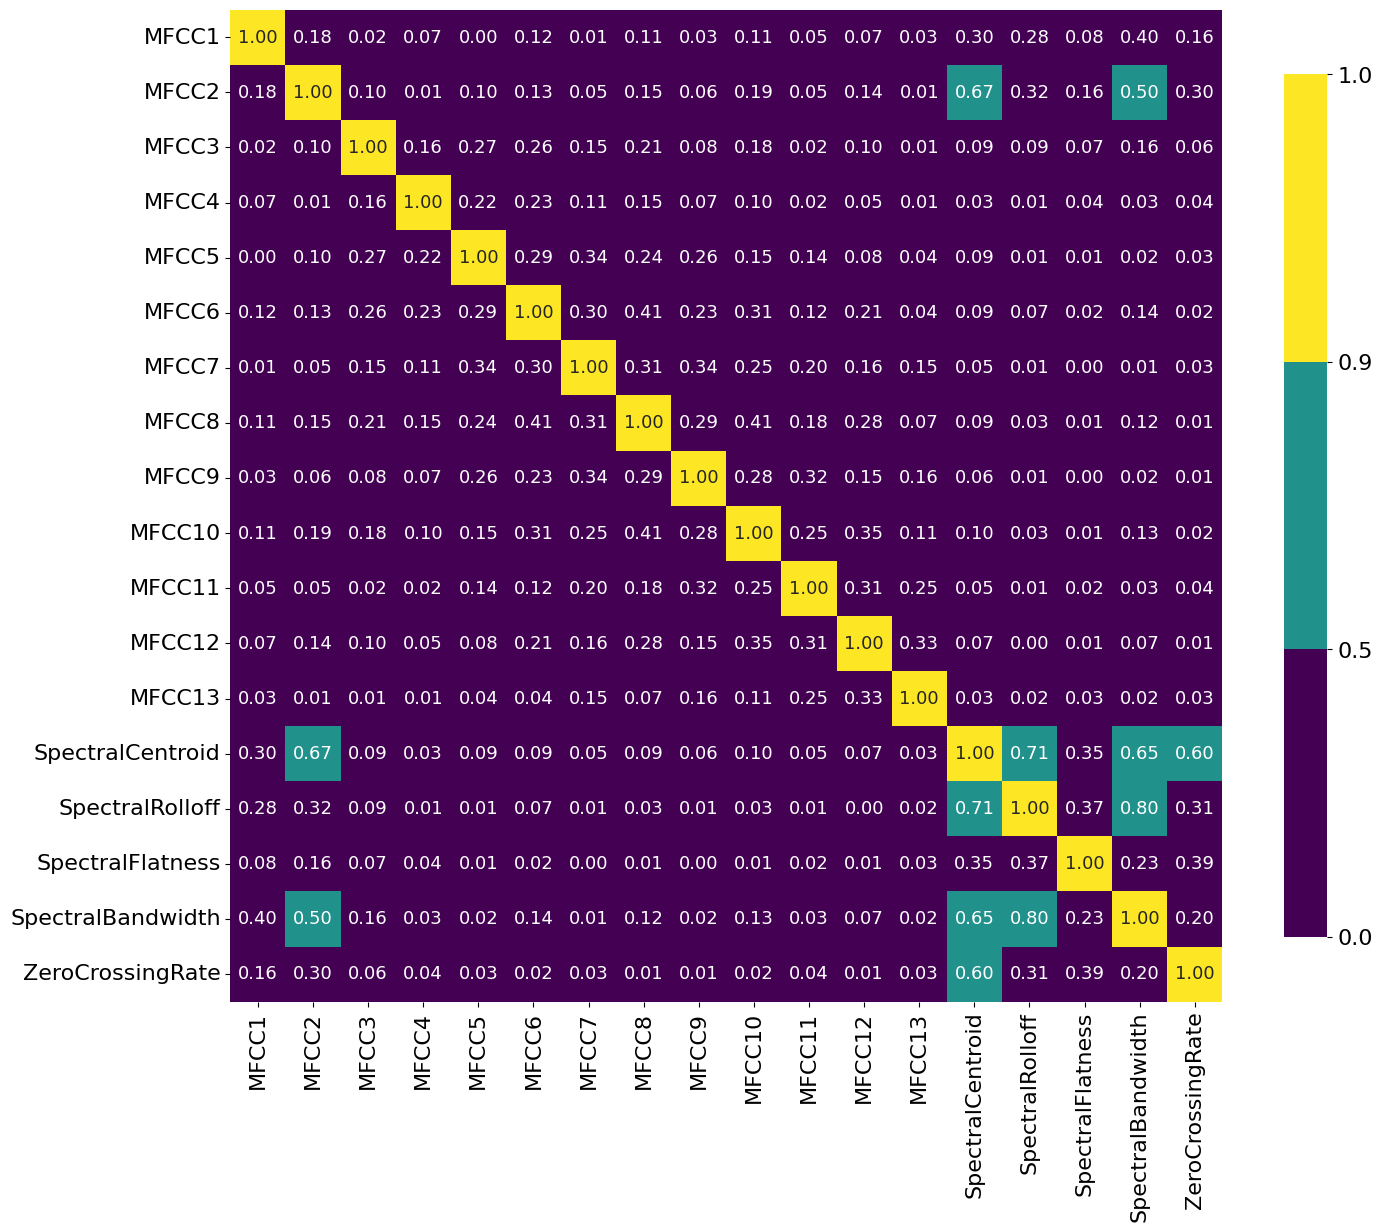

                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept        Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.9786 18.0000 8770.0000 10.6713 0.0000
         Pillai's trace 0.0214 18.0000 8770.0000 10.6713 0.0000
 Hotelling-Lawley trace 0.0219 18.0000 8770.0000 10.6713 0.0000
    Roy's greatest root 0.0219 18.0000 8770.0000 10.6713 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
         Nation         Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.9891 18.0000 8770.0000  5.3789 0.0000
         Pillai's trace 0.0109 18.0000 8770.0000  5.3789 0.

In [21]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import get_cmap
import seaborn as sns

csvfilename = r'C:\python\gits\early-techno\matrix25-12-21-allMFCCskew.csv'
df = pd.read_csv(csvfilename, index_col=False)

df_selected = df.iloc[:, 3:]
correlation_matrix = df_selected.corr()

# Take the absolute value
abs_correlation_matrix = correlation_matrix.abs()

# Set up the matplotlib figure
plt.figure(figsize=(16, 14))

# Get viridis color map and sample specific colors for the defined ranges
viridis_cmap = get_cmap('viridis')
colors = [viridis_cmap(viridis_cmap.N // 4 * 0),   # Blue (lower range)
          viridis_cmap(viridis_cmap.N // 4 * 2),   # Green (middle range)
          viridis_cmap(viridis_cmap.N - 1)]         # Yellow (upper range)

# Create custom colormap and normalization
cmap = ListedColormap(colors)
boundaries = [0, 0.5, 0.9, 1]  # Define the boundaries for the color categories
norm = BoundaryNorm(boundaries, ncolors=len(colors), clip=False)

# Draw the heatmap
ax=sns.heatmap(abs_correlation_matrix, 
            annot=True,         # Annotate with the correlation values
            fmt=".2f",         # Format to two decimal places
            cmap=cmap,         # Use the custom colormap
            norm=norm,         # Use the custom normalization
            square=True,       # Make cells square
            annot_kws={"size": 13},  # Increase annotation size
            cbar_kws={"shrink": .8})  # Color bar size

cbar = ax.collections[0].colorbar  # Get the colorbar
cbar.ax.tick_params(labelsize=16) 
# Title and labels
ax.tick_params(axis='both', labelsize=16)  # Change tick label size
#plt.title('Discretized Absolute Spearman Correlation Matrix using Viridis')
plt.savefig('correlation_matrix_skewmfcc.pdf', format='pdf',bbox_inches='tight')
plt.show()

from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('MFCC1 + MFCC2 + MFCC3 + MFCC4 + MFCC5 + MFCC6 + MFCC7 + MFCC8 + MFCC9 + MFCC10 + MFCC11 + MFCC12 + MFCC13 + +SpectralCentroid + SpectralRolloff + SpectralFlatness + SpectralBandwidth + ZeroCrossingRate ~ Nation * Year', data=df)
# Print the results
print(manova.mv_test())